<a href="https://colab.research.google.com/github/dproiectum/ML-Heart_Disease_Prediction/blob/main/ML_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1.Initialization

### Librairies

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve
)
import joblib
from google.colab import drive
import matplotlib.pyplot as plt


### Dataset - kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/heat-disease-predication-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heat-disease-predication-dataset' dataset.
Path to dataset files: /kaggle/input/heat-disease-predication-dataset


In [ ]:
from pathlib import Path
import os

file_name = os.listdir(path)[0]

# Get the list of files in the directory and take the first one (assuming it's the CSV)
csv_path = Path(path) / file_name

df = pd.read_csv(csv_path)

In [ ]:
print(df)

       Age  Gender  Weight  Height   BMI  Smoking Alcohol_Intake  \
0       48    Male      78     157  26.4    Never            NaN   
1       35  Female      73     163  33.0    Never            Low   
2       79  Female      88     152  32.3    Never            NaN   
3       75    Male     106     171  37.4    Never       Moderate   
4       34  Female      65     191  18.5  Current            NaN   
...    ...     ...     ...     ...   ...      ...            ...   
49995   74    Male     104     155  29.9  Current            NaN   
49996   53    Male      95     163  35.8    Never            Low   
49997   38  Female      91     197  32.3   Former            Low   
49998   68    Male     115     152  18.6    Never           High   
49999   53  Female      81     193  21.7    Never            Low   

      Physical_Activity       Diet Stress_Level  ...  Diabetes  \
0             Sedentary    Healthy       Medium  ...         0   
1                Active    Average         High  ..

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

### Configuration

In [ ]:
TARGET_COL = "Heart_Disease"

NUMERIC_COLS = [
    "Age", "Weight", "Height", "BMI", "Systolic_BP", "Diastolic_BP", "Heart_Rate", "Blood_Sugar_Fasting", "Cholesterol_Total"
]

CATEGORICAL_COLS = [
    "Gender", "Smoking", "Alcohol_Intake", "Physical_Activity", "Diet", "Stress_Level"
]

BINARY_COLS = [
    "Hypertension", "Diabetes", "Hyperlipidemia", "Family_History", "Previous_Heart_Attack"
]

BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3
HIDDEN_DIMS = [64, 32, 16]
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/DL_DE2"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Les fichiers seront sauvegardés dans :", SAVE_DIR)

Device utilisé : cpu


##2.Preparation

### Preprocessing

In [ ]:
df = pd.read_csv(csv_path)

X_raw = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].values.astype(np.float32)

# Encodage : variables numériques -> standardisation
#            variables catégorielles -> one-hot encoding
#            variables binaires -> laissées telles quelles (déjà 0/1)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS),
        ("bin", "passthrough", BINARY_COLS),
    ]
)

X_processed = preprocessor.fit_transform(X_raw)
input_dim = X_processed.shape[1]
print(f"Nombre de features après encodage : {input_dim}")

# Sauvegarde du préprocesseur pour la démo Streamlit
joblib.dump(preprocessor, "preprocessor.joblib")

# Split train / validation / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_processed, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")



Nombre de features après encodage : 32
Train : 35000 | Val : 7500 | Test : 7500


In [ ]:
X_processed

array([[-0.44771329, -0.32392531, -1.21079863, ...,  1.        ,
         1.        ,  0.        ],
       [-1.34811841, -0.5712902 , -0.79471662, ...,  1.        ,
         1.        ,  0.        ],
       [ 1.69940662,  0.17080446, -1.55753363, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.14033261,  0.3192234 ,  1.56308139, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.93752536,  1.50657485, -1.55753363, ...,  0.        ,
         0.        ,  0.        ],
       [-0.10140362, -0.17550638,  1.28569339, ...,  0.        ,
         0.        ,  0.        ]])

### Dataset PyTorch

In [ ]:
class HeartDiseaseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(HeartDiseaseDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(HeartDiseaseDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(HeartDiseaseDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)



##3.Modelization & Training

### Neural network architecture

In [ ]:
class HeartDiseaseNN(nn.Module):
    """
    MLP simple pour classification binaire à partir de données tabulaires.
    - Plusieurs couches cachées avec BatchNorm + ReLU + Dropout pour
      limiter le surapprentissage (dataset tabulaire de taille moyenne).
    - Une seule sortie (logit), la fonction sigmoïde est appliquée
      implicitement par BCEWithLogitsLoss (plus stable numériquement).
    """
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            # Cela s'appiquent à chaque couche caché du réseau
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # logit de sortie
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


model = HeartDiseaseNN(input_dim=input_dim, hidden_dims=HIDDEN_DIMS).to(device)
print(model)

criterion = nn.BCEWithLogitsLoss() # fonction de perte
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5) # changer le LR pendant l'entrainement pour des pas plus petits quand ça s'approche a l'extrêmum



HeartDiseaseNN(
  (network): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)


### Training

In [ ]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad(): # ne pas calculer le gradiant
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch) # valeur avant fonction d'activaition
            loss = criterion(logits, y_batch) # comparer la prédiction avec la vraie valeur
            total_loss += loss.item() * X_batch.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc


best_val_loss = float("inf")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    # Accuracy sur le train (recalculée en mode eval, sans dropout/batchnorm actifs)
    _, train_acc = evaluate(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    # NB : le test set n'intervient dans AUCUNE décision (ni scheduler, ni
    # sélection du meilleur checkpoint) - on l'évalue ici uniquement pour
    # tracer sa courbe, jamais pour choisir le modèle (afin d'éviter toute
    # fuite d'information depuis le test set).
    test_loss, test_acc = evaluate(model, test_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_heart_disease_model.pt"))

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Val acc: {val_acc:.4f}")

print("\nEntraînement terminé.")



Epoch   1/50 | Train loss: 0.0783 | Val loss: 0.0304 | Val acc: 0.9924
Epoch   5/50 | Train loss: 0.0803 | Val loss: 0.0330 | Val acc: 0.9912
Epoch  10/50 | Train loss: 0.0779 | Val loss: 0.0304 | Val acc: 0.9941
Epoch  15/50 | Train loss: 0.0810 | Val loss: 0.0305 | Val acc: 0.9932
Epoch  20/50 | Train loss: 0.0763 | Val loss: 0.0316 | Val acc: 0.9897
Epoch  25/50 | Train loss: 0.0772 | Val loss: 0.0313 | Val acc: 0.9900
Epoch  30/50 | Train loss: 0.0817 | Val loss: 0.0329 | Val acc: 0.9913
Epoch  35/50 | Train loss: 0.0743 | Val loss: 0.0330 | Val acc: 0.9912
Epoch  40/50 | Train loss: 0.0795 | Val loss: 0.0347 | Val acc: 0.9875
Epoch  45/50 | Train loss: 0.0806 | Val loss: 0.0316 | Val acc: 0.9917
Epoch  50/50 | Train loss: 0.0811 | Val loss: 0.0342 | Val acc: 0.9929

Entraînement terminé. Meilleur modèle sauvegardé dans 'best_heart_disease_model.pt'.


##4.Evaluation

### Final evaluation

In [ ]:
model.load_state_dict(torch.load("best_heart_disease_model.pt"))
model.eval()

all_probs, all_preds, all_targets = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy().flatten().astype(int))

print("\n=== Résultats sur le jeu de test ===")
print(f"Accuracy  : {accuracy_score(all_targets, all_preds):.4f}")
print(f"Precision : {precision_score(all_targets, all_preds):.4f}")
print(f"Recall    : {recall_score(all_targets, all_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(all_targets, all_probs):.4f}")
print("\nRapport de classification :")
print(classification_report(all_targets, all_preds))


=== Résultats sur le jeu de test ===
Accuracy  : 0.9952
Precision : 0.9945
Recall    : 0.9951
F1-score  : 0.9948
ROC-AUC   : 0.9999

Matrice de confusion :
[[4005   19]
 [  17 3459]]

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4024
           1       0.99      1.00      0.99      3476

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500



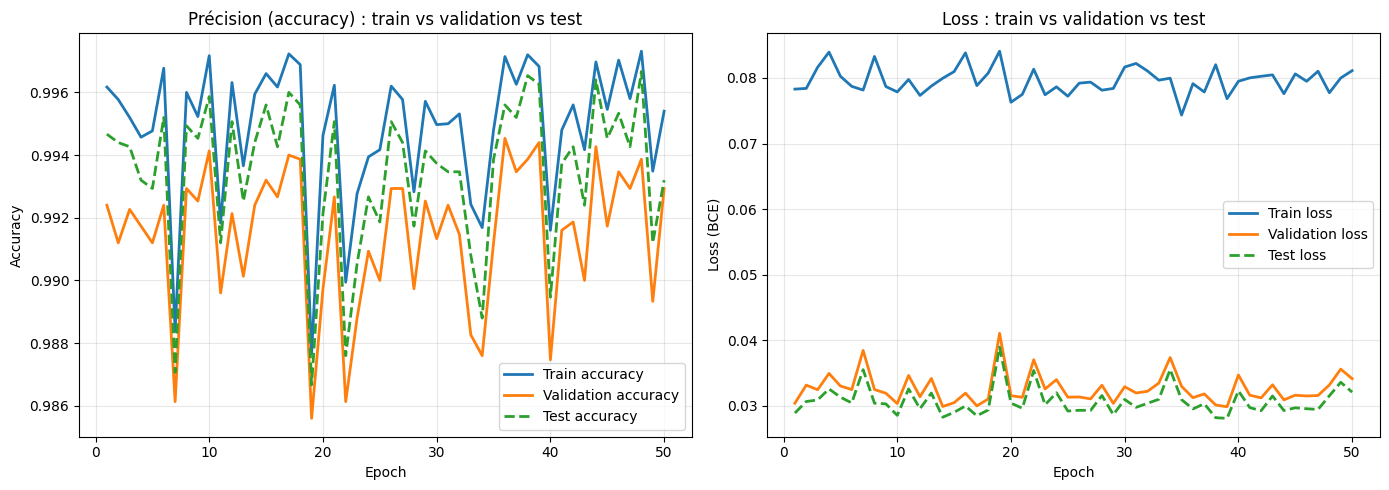

In [ ]:

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Courbes d'accuracy ---
axes[0].plot(epochs_range, history["train_acc"], label="Train accuracy", linewidth=2)
axes[0].plot(epochs_range, history["val_acc"], label="Validation accuracy", linewidth=2)
axes[0].plot(epochs_range, history["test_acc"], label="Test accuracy", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Précision (accuracy) : train vs validation vs test")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Courbes de loss (pour référence / diagnostic overfitting) ---
axes[1].plot(epochs_range, history["train_loss"], label="Train loss", linewidth=2)
axes[1].plot(epochs_range, history["val_loss"], label="Validation loss", linewidth=2)
axes[1].plot(epochs_range, history["test_loss"], label="Test loss", linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (BCE)")
axes[1].set_title("Loss : train vs validation vs test")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()


plt.show()

# print(f"Courbes sauvegardées dans : {curves_path}")

# Sauvegarde aussi l'historique brut (utile pour retracer le graphique
# plus tard, ou l'inclure dans un rapport, sans réentraîner le modèle)
history_df = pd.DataFrame(history)
history_df.insert(0, "epoch", list(epochs_range))
history_csv_path = os.path.join(SAVE_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)
print(f"Historique (loss/accuracy par epoch) sauvegardé dans : {history_csv_path}")


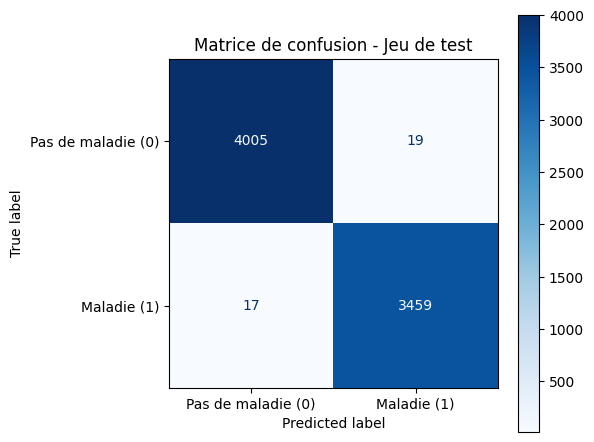

Matrice de confusion sauvegardée dans : /content/drive/MyDrive/DL_DE2/dashboard/confusion_matrix.png


In [ ]:
# --- Tracé et sauvegarde de la matrice de confusion ---
cm = confusion_matrix(all_targets, all_preds)
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de maladie (0)", "Maladie (1)"])
disp.plot(ax=ax_cm, cmap="Blues", colorbar=True, values_format="d")
ax_cm.set_title("Matrice de confusion - Jeu de test")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "dashboard", "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Matrice de confusion sauvegardée dans : {cm_path}")

### Threshold ajustment

In [ ]:
# ----------------------------------------------------------------------
# 7. Change the threshold of classification to reduce the false negatives
# ----------------------------------------------------------------------
model.load_state_dict(torch.load("best_heart_disease_model.pt"))
model.eval()

all_probs, all_preds, all_targets = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs >= 0.3).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy().flatten().astype(int))

print("\n=== Résultats sur le jeu de test ===")
print(f"Accuracy  : {accuracy_score(all_targets, all_preds):.4f}")
print(f"Precision : {precision_score(all_targets, all_preds):.4f}")
print(f"Recall    : {recall_score(all_targets, all_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(all_targets, all_probs):.4f}")
print("\nRapport de classification :")
print(classification_report(all_targets, all_preds))


=== Résultats sur le jeu de test ===
Accuracy  : 0.9875
Precision : 0.9745
Recall    : 0.9991
ROC-AUC   : 0.9999

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4024
           1       0.97      1.00      0.99      3476

    accuracy                           0.99      7500
   macro avg       0.99      0.99      0.99      7500
weighted avg       0.99      0.99      0.99      7500



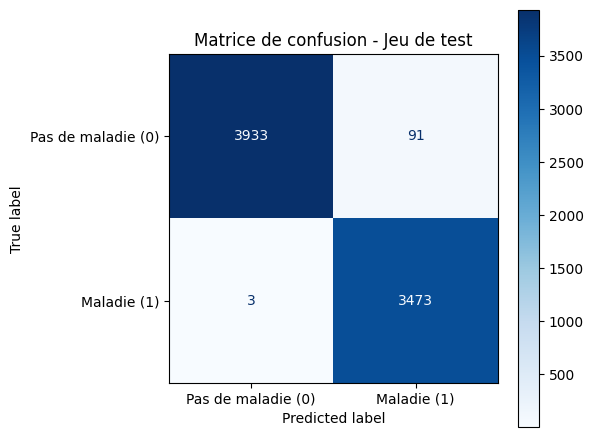

Matrice de confusion sauvegardée dans : /content/drive/MyDrive/DL_DE2/dashboard/confusion_matrix_modification.png


In [ ]:
# --- Tracé et sauvegarde de la matrice de confusion ---
cm = confusion_matrix(all_targets, all_preds)
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de maladie (0)", "Maladie (1)"])
disp.plot(ax=ax_cm, cmap="Blues", colorbar=True, values_format="d")
ax_cm.set_title("Matrice de confusion - Jeu de test")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "dashboard", "confusion_matrix_modification.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Matrice de confusion sauvegardée dans : {cm_path}")

##5.Saving model

In [ ]:
final_model_path = os.path.join(SAVE_DIR, "heart_disease_model_full.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dims": HIDDEN_DIMS,
}, final_model_path)

print(f"\nModèle final sauvegardé dans '{final_model_path}' "
      f"(à charger dans l'application Streamlit avec le même preprocessor.joblib "
      f"depuis '{SAVE_DIR}').")

# torch.save({
#     "model_state_dict": model.state_dict(),
#     "input_dim": input_dim,
#     "hidden_dims": HIDDEN_DIMS,
# }, "heart_disease_model_full.pt")

# print("\nModèle final sauvegardé dans 'heart_disease_model_full.pt' "
#       "(à charger dans l'application Streamlit avec le même preprocessor.joblib).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Les fichiers seront sauvegardés dans : /content/drive/MyDrive/DL_DE2

Modèle final sauvegardé dans '/content/drive/MyDrive/DL_DE2/heart_disease_model_full.pt' (à charger dans l'application Streamlit avec le même preprocessor.joblib depuis '/content/drive/MyDrive/DL_DE2').
